# 07. Collaborative Filtering Recommender

This notebook implements a Collaborative Filtering model using SVD from the `Surprise` library.

In [1]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, SVD
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')


## 1. Load Data

In [2]:
train_path = 'train_interactions.csv'
train_df = pd.read_csv(train_path)
print(f'Train shape: {train_df.shape}')

# We only need authorid, recipeid, and rating
train_df = train_df[['authorid', 'recipeid', 'rating']]
train_df.dropna(inplace=True)
print(f'Train shape after dropping NaNs: {train_df.shape}')

Train shape: (616473, 10)
Train shape after dropping NaNs: (616473, 3)


C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_20420\3718528260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=train_df, palette='Oranges_d')


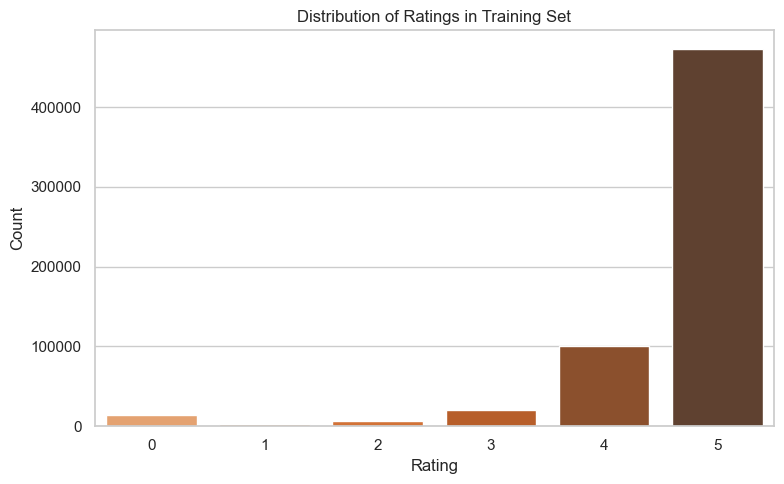

In [3]:
# Plot the distribution of ratings in the training set
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=train_df, palette='Oranges_d')
plt.title('Distribution of Ratings in Training Set')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Prepare Data for Surprise

The `Reader` parses the file containing the ratings. We specify the rating_scale.

In [4]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(train_df[['authorid', 'recipeid', 'rating']], reader)
trainset = data.build_full_trainset()

## 3. Train SVD Model

In [5]:
algo = SVD(n_factors=50, random_state=42)
print('Training SVD model...')
algo.fit(trainset)
print('Training completed.')

Training SVD model...
Training completed.


## 4. Save Model for Evaluation

In [6]:
os.makedirs('output', exist_ok=True)

with open('output/svd_model.pkl', 'wb') as f:
    pickle.dump(algo, f)
    
print('Saved SVD model to output/svd_model.pkl')

Saved SVD model to output/svd_model.pkl
